### Imports

In [1]:
import os
import sys
import time
import matplotlib.pyplot as plt
import time

import numpy as np

import cupy as cp
from cupy import cublas
from cupy._core import _dtype
from cupy.cuda import device
from cupy_backends.cuda.libs import cublas as _cublas
from cupyx.scipy.sparse import _csr
from cupyx.scipy.sparse.linalg import _interface
from cupyx.scipy.sparse import csr_matrix
from cupyx.scipy.sparse.linalg import LinearOperator

from cupy_backends.cuda.libs import cusparse as _cusparse
from cupyx import cusparse

# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)
sys.path.append('.') 

#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad

# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

### cuPY Functions

In [2]:
def _get_atol_rtol(name, b_norm, atol=0., rtol=1e-5):
    """
    A helper function to handle tolerance normalization
    """
    if atol == 'legacy' or atol is None or atol < 0:
        msg = (f"'scipy.sparse.linalg.{name}' called with invalid `atol`={atol}; "
            "if set, `atol` must be a real, non-negative number.")
        raise ValueError(msg)
    
    print(f'         * rtol: {float(rtol)}')
    
    atol = max(float(atol), float(rtol) * float(b_norm))
    print(f'         * final tolerance: {atol}')
    
    return atol, rtol

In [3]:
def _make_fast_matvec(A):
    if _csr.isspmatrix_csr(A) and cusparse.check_availability('spmv'):
        handle = device.get_cusparse_handle()
        op_a = _cusparse.CUSPARSE_OPERATION_NON_TRANSPOSE
        alpha = numpy.array(1.0, A.dtype)
        beta = numpy.array(0.0, A.dtype)
        cuda_dtype = _dtype.to_cuda_dtype(A.dtype)
        alg = _cusparse.CUSPARSE_MV_ALG_DEFAULT
        x = cp.empty((A.shape[0],), dtype=A.dtype)
        y = cp.empty((A.shape[0],), dtype=A.dtype)
        desc_A = cusparse.SpMatDescriptor.create(A)
        desc_x = cusparse.DnVecDescriptor.create(x)
        desc_y = cusparse.DnVecDescriptor.create(y)
        buff_size = _cusparse.spMV_bufferSize(
            handle, op_a, alpha.ctypes.data, desc_A.desc, desc_x.desc,
            beta.ctypes.data, desc_y.desc, cuda_dtype, alg)
        buff = cp.empty(buff_size, cp.int8)
        del x, desc_x, y, desc_y

        def matvec(x):
            y = cp.empty_like(x)
            desc_x = cusparse.DnVecDescriptor.create(x)
            desc_y = cusparse.DnVecDescriptor.create(y)
            _cusparse.spMV(
                handle, op_a, alpha.ctypes.data, desc_A.desc, desc_x.desc,
                beta.ctypes.data, desc_y.desc, cuda_dtype, alg, buff.data.ptr)
            return y

        return matvec
    return None

In [4]:
def _make_system(A, M, x0, b):
    """Forza un sistema Ax = b complejo (usa complex64 siempre)."""
    target_dtype = cp.complex64

    fast_matvec = _make_fast_matvec(A)
    A = _interface.aslinearoperator(A)

    if fast_matvec is not None:
        A = _interface.LinearOperator(A.shape, matvec=fast_matvec,
                                      rmatvec=A.rmatvec, dtype=target_dtype)
    else:
        A = _interface.LinearOperator(A.shape, matvec=A.matvec,
                                      rmatvec=A.rmatvec, dtype=target_dtype)

    if A.shape[0] != A.shape[1]:
        raise ValueError(f'expected square matrix (shape: {A.shape})')

    n = A.shape[0]
    if not (b.shape == (n,) or b.shape == (n, 1)):
        raise ValueError('b has incompatible dimensions')
    b = b.astype(target_dtype).ravel()

    if x0 is None:
        x = cp.zeros((n,), dtype=target_dtype)
    else:
        if not (x0.shape == (n,) or x0.shape == (n, 1)):
            raise ValueError('x0 has incompatible dimensions')
        x = x0.astype(target_dtype).ravel()

    if M is None:
        M = _interface.IdentityOperator(shape=A.shape, dtype=target_dtype)
    else:
        fast_matvec = _make_fast_matvec(M)
        M = _interface.aslinearoperator(M)
        if fast_matvec is not None:
            M = _interface.LinearOperator(M.shape, matvec=fast_matvec,
                                          rmatvec=M.rmatvec, dtype=target_dtype)
        else:
            M = _interface.LinearOperator(M.shape, matvec=M.matvec,
                                          rmatvec=M.rmatvec, dtype=target_dtype)
        if A.shape != M.shape:
            raise ValueError('matrix and preconditioner have different shapes')

    return A, M, x, b


In [5]:
def bicgstab_cupy(A, b, x0=None, *, rtol=1e-7, atol=0.0, maxiter=None, M=None, callback=None):
    print("     * BICGSTAB (CuPy version)")
    A, M, x, b = _make_system(A, M, x0, b)
    bnrm2 = cp.linalg.norm(b)

    atol, _ = _get_atol_rtol('bicgstab', bnrm2, atol, rtol)

    if bnrm2 == 0:
        return x, 0

    n = len(b)
    dotprod = cp.vdot if cp.iscomplexobj(x) else cp.dot

    if maxiter is None:
        maxiter = n * 10000
    print("         * maxiter: ", maxiter)

    matvec = A.matvec
    psolve = M.matvec

    rhotol = cp.finfo(x.dtype).eps**2
    omegatol = rhotol

    rho_prev, omega, alpha, p, v = None, None, None, None, None

    r = b - matvec(x) if cp.any(x) else b.copy()
    rtilde = r.copy()

    for iteration in range(maxiter):
        print("             .. iteration:", iteration)
        tol_ = cp.linalg.norm(r)
        print("       -> actual tol:", float(tol_), "vs", float(atol))
        if tol_ < atol:
            print("        * CGM converged in", iteration, "iterations")
            return x, 0

        rho = dotprod(rtilde, r)
        if cp.abs(rho) < rhotol:
            print("        ! Rho breakdown")
            return x, -10

        if iteration > 0:
            if cp.abs(omega) < omegatol:
                print("        ! Omega breakdown")
                return x, -11

            beta = (rho / rho_prev) * (alpha / omega)
            p -= omega * v
            p *= beta
            p += r
        else:
            s = cp.empty_like(r)
            p = r.copy()

        phat = psolve(p)
        v = matvec(phat)
        rv = dotprod(rtilde, v)
        if rv == 0:
            print("        ! Breakdown (rtilde·v = 0)")
            return x, -11
        alpha = rho / rv
        r -= alpha * v
        s[:] = r[:]

        if cp.linalg.norm(s) < atol:
            x += alpha * phat
            print("        * CGM converged (s norm check)")
            return x, 0

        shat = psolve(s)
        t = matvec(shat)
        omega = dotprod(t, s) / dotprod(t, t)
        x += alpha * phat
        x += omega * shat
        r -= omega * t
        rho_prev = rho

        if callback:
            callback(x)

    print("        ! Reached maxiter without full convergence")
    return x, maxiter

In [6]:
def binned_statistic_2d_cupy(x, y, values, statistic='mean', bins=10, range=None, expand_binnumbers=False):
    if isinstance(bins, (list, tuple)) and len(bins) == 2:
        x_edges, y_edges = cp.asarray(bins[0]), cp.asarray(bins[1])
        bins_x, bins_y = len(x_edges) - 1, len(y_edges) - 1
    else:
        bins_x = bins_y = bins
        hist, x_edges, y_edges = cp.histogram2d(x, y, bins=bins, range=range)

    x_bin = cp.digitize(x, x_edges) - 1
    y_bin = cp.digitize(y, y_edges) - 1
    valid = (x_bin >= 0) & (x_bin < bins_x) & (y_bin >= 0) & (y_bin < bins_y)
    x_bin, y_bin, values = x_bin[valid], y_bin[valid], values[valid]
    bin_idx = (x_bin * bins_y + y_bin).astype(cp.int32)

    if statistic == 'count':
        counts = cp.zeros(bins_x * bins_y, dtype=cp.float32)
        cp.ElementwiseKernel(
            'int32 idx',
            'raw float32 out',
            'atomicAdd(&out[idx], 1.0f)',
            'bincount_count_kernel'
        )(bin_idx, counts)
        bin_stat = counts.reshape(bins_x, bins_y)

    else:
        # Prealocar arrays de salida
        real_out = cp.zeros(bins_x * bins_y, dtype=cp.float32)
        cp.ElementwiseKernel(
            'int32 idx, float32 val',
            'raw float32 out',
            'atomicAdd(&out[idx], val)',
            'bincount_real_kernel'
        )(bin_idx, cp.real(values).astype(cp.float32), real_out)
        real_vals = real_out.reshape(bins_x, bins_y)

        if cp.iscomplexobj(values):
            imag_out = cp.zeros(bins_x * bins_y, dtype=cp.float32)
            cp.ElementwiseKernel(
                'int32 idx, float32 val',
                'raw float32 out',
                'atomicAdd(&out[idx], val)',
                'bincount_imag_kernel'
            )(bin_idx, cp.imag(values).astype(cp.float32), imag_out)
            imag_vals = imag_out.reshape(bins_x, bins_y)
            sum_vals = real_vals + 1j * imag_vals
        else:
            sum_vals = real_vals

        if statistic == 'sum':
            bin_stat = sum_vals
        elif statistic == 'mean':
            count_out = cp.zeros(bins_x * bins_y, dtype=cp.float32)
            cp.ElementwiseKernel(
                'int32 idx',
                'raw float32 out',
                'atomicAdd(&out[idx], 1.0f)',
                'bincount_count_kernel'
            )(bin_idx, count_out)
            count_vals = count_out.reshape(bins_x, bins_y)
            bin_stat = cp.divide(sum_vals, count_vals, where=(count_vals > 0))
        else:
            raise ValueError(f"Unsupported statistic: {statistic}")

    if expand_binnumbers:
        return bin_stat, x_edges, y_edges, (x_bin, y_bin)

    return bin_stat, x_edges, y_edges


In [7]:
def linear_operator(A, size):
    def dot_product(x):
        return A.dot(x)

    return LinearOperator(size, matvec=dot_product)

In [8]:
def P_k(r, k):
    if k == 0:
        return cp.ones_like(r)  # P_0(r) = 1
    elif k == 1:
        return 4*r +1  # P_1(r) = 4r + 1
    elif k == 2:
        return (35/3)*r**2 +6*r + 1  # P_2(r) = 35r^2 + 18r + 3

In [9]:
def kernel_row(u, v, i, u2 = None, v2 = None):
    def power_spectrum(q, m, c):
        if not cp.isscalar(q):  
            q[q == 0] = min_freq
        elif q == 0:
            q = min_freq
        return (q**m)*cp.exp(c)
    
    j, k = 4, 1
    H = 2*1.897367*l

    q = cp.hypot(u, v)
    power_spectrum_q1 = power_spectrum(q, m, c)
    uh = u/H
    vh = v/H

    q2 = uh2 = vh2 =  None

    if isinstance(u2, cp.ndarray):
        q2 = cp.hypot(u2[i], v2[i])
        uh2 = u2[i]/H
        vh2 = v2[i]/H
    else:
        q2 = q[i]
        uh2 = uh[i]
        vh2 = vh[i]

    amp = cp.sqrt(power_spectrum_q1 * power_spectrum(q2, m, c))
    
    r_normalized = cp.sqrt((uh-uh2)**2 + (vh-vh2)**2)
    factor = (1 - r_normalized)**j
    factor[r_normalized > 1] = 0

    return amp * factor * P_k(r_normalized, k)

In [10]:
def create_sparse_kernel(kernel_function, u, v, u2=None, v2=None):
    if isinstance(u2, cp.ndarray):
        size1 = len(u2)
        size2 = len(u)
    else:
        size1 = size2 = len(u)

    data = cp.array([], dtype=cp.float32)
    indices = cp.array([], dtype=cp.int32)
    indptr = cp.zeros(size1 + 1, dtype=cp.int32)

    for i in range(size1):
        row = kernel_function(u, v, i, u2=u2, v2=v2) if isinstance(u2, cp.ndarray) else kernel_function(u, v, i)
        
        non_zero_indices = cp.nonzero(row)[0]
        kernel_values = row[non_zero_indices]

        data = cp.concatenate((data, kernel_values))
        indices = cp.concatenate((indices, non_zero_indices))
        indptr[i + 1] = data.size

    size = (size1, size2)

    kernel_csr = csr_matrix((data, indices, indptr), shape=size)
    
    kernel_csr = linear_operator(kernel_csr, size)

    return kernel_csr

In [11]:
def recovering_sol(C):
    V_1_m = S11_linearOp.matvec(C)
    V_2_m = S12_T_linearOp.matvec(C)
    
    V_m = cp.zeros((N, N), dtype = 'c16')
    
    data_coords = cp.unravel_index(data_index.flatten(), (N, N))
    no_data_coords = cp.unravel_index(no_data_index.flatten(), (N, N))
    
    V_m[data_coords] = V_1_m
    V_m[no_data_coords] = V_2_m

    u_m = cp.zeros((N, N))
    v_m = cp.zeros((N, N))
    
    u_m[data_coords] = u_gridded_data
    u_m[no_data_coords] = u_gridded_no_data
    
    v_m[data_coords] = v_gridded_data
    v_m[no_data_coords] = v_gridded_no_data
    
    return V_m

### From now on paralelized version with cuPY

In [12]:
N = 100

In [13]:
#os.system("module avail cuda")

In [14]:
#os.system("module load cuda-rhel8/11.7")

In [15]:
print(cp.cuda.runtime.runtimeGetVersion())

11080


In [16]:
cp.cuda.runtime.getDeviceCount()

1

In [17]:
cp.cuda.Device(0).use() 

<CUDA Device 0>

In [18]:
mempool = cp.get_default_memory_pool()
mempool.free_all_blocks()

In [19]:
mem_info = cp.cuda.Device(0).mem_info  # Para la GPU 0
mem_libre_MB = mem_info[0] / 1e6 /1024  # Convertir de bytes a MB
mem_total_MB = mem_info[1] / 1e6 /1024

print(f"Memoria libre: {mem_libre_MB:.2f} GB")
print(f"Memoria total: {mem_total_MB:.2f} GB")

Memoria libre: 24.58 GB
Memoria total: 24.81 GB


In [20]:
os.system("nvidia-smi")

Sat May  3 13:26:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.142                Driver Version: 550.142        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:B3:00.0 Off |                  Off |
| 30%   33C    P2             22W /  230W |     229MiB /  24564MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

0

In [21]:
def info_mem():
    mempool = cp.get_default_memory_pool()
    print(f"Used memory: {(mempool.used_bytes() / 1e6):.2f} MB")
    print(f"Free memory in pool: {(mempool.free_bytes() / 1e6) :.2f} MB")

### Data

In [22]:
disk_name = 'AS209 1mm'

# Huang 2018 
inc = 34.97
pa = 85.76
dra = 1.9e-3
ddec = -2.5e-3
Rout = 3 #arcsecs

# UVtable
dir = "./../../data/"
data_file = dir +'AS209_continuum_prom_1chan_30s_keepflagsFalse.txt'

 # load data||
u, v, Re, Imag, Weights = cp.loadtxt(data_file, unpack = True)
Vis = Re + Imag*1j

u_np, v_np, Re_np, Imag_np, Weights_np = np.loadtxt(data_file, unpack = True)
Vis_np = Re_np + Imag_np*1j


#u, v = u.astype(cp.float32), v.astype(cp.float32)
#Weights = Weights.astype(cp.float32)
#Re = Re.astype(cp.float32)
#Imag = Imag.astype(cp.float32)

## Frank2D

### Redifining classes

#### FT

In [23]:
class FourierTransform2D_GPU(object):
    def __init__(self, Rmax, N, Geometry):
        # Remember that now N is to create N**2 points in image plane.
        self._Xmax = Rmax #Rad
        self._Ymax = Rmax
        self._Nx = N 
        self._Ny = N
        self._N2 = self._Nx*self._Ny # Number of points we want to use in the 2D-DFT.

        # Real space collocation points
        self._x = cp.linspace(-self._Xmax, self._Xmax, self._Nx, endpoint=False) # rad
        self._y = cp.linspace(-self._Ymax, self._Ymax, self._Ny, endpoint=False) # rad
        x_, y_ = cp.meshgrid(self._x, self._y, indexing='ij')
        # x_n.shape = N**2 X 1, so now, we have N**2 collocation points in the image plane.
        x_n, y_n = x_.reshape(-1), y_.reshape(-1)

        self._dx = 2*self._Xmax/self._Nx
        self._dy = 2*self._Ymax/self._Ny

        # Frequency space collocation points.
        self._u = cp.fft.fftfreq(self._Nx, d = self._dx)# unshifted
        self._v = cp.fft.fftfreq(self._Ny, d = self._dy) # unshifted
        self._u_shifted = cp.fft.fftshift(self._u)
        self._v_shifted = cp.fft.fftshift(self._v)
        
        u_, v_ = cp.meshgrid(self._u, self._v, indexing='ij') 
        # u_n.shape = N**2 X 1, so now, we have N**2 collocation points.
        u_n, v_n = u_.reshape(-1), v_.reshape(-1)

        self._Xn = x_n
        self._Yn = y_n
        self._Un = u_n
        self._Vn = v_n

    def get_collocation_points(self):
        return cp.array([self._Xn, self._Yn]), cp.array([self._Un, self._Vn])

    def coefficients(self, u = None, v = None, x = None, y = None, direction="forward"):
        #start_time = time.time()
        if direction == 'forward':
            ## Normalization is dx*dy since we the DFT to be an approximation
            ## of the integral (which depends on the area)
            norm = 4*self._Xmax*self._Ymax/self._N2
            factor = -2j*cp.pi
            
            X, Y = self._Xn, self._Yn
            if u is None:
                u = self._Un
                v = self._Vn
        elif direction == 'backward':
            ## Correcting for the normalization above 1/N is replaced by this:
            norm = 1 / (4*self._Xmax*self._Ymax)
            factor = 2j*cp.pi
            
            X, Y = self._Un, self._Vn
            if u is None:
                u = self._Xn
                v = self._Yn
        else:
            raise AttributeError("direction must be one of {}"
                                 "".format(['forward', 'backward']))
        H = norm * cp.exp(factor*(cp.outer(u, X) + cp.outer(v, Y)))
        return H

    def fast_transform(self, element, direction = 'forward'):
        if direction == 'forward':
            return cp.fft.fftshift(cp.fft.fft2(element.reshape(self._Nx, self._Ny)).real)*(self._dx * self._dy)
        elif direction == 'backward':
            return cp.fft.fftshift(cp.fft.ifft2(element.reshape(self._Nx, self._Ny)).real)/(self._dx * self._dy)
        else:
            raise AttributeError("direction must be one of {}"
                                 "".format(['forward', 'backward']))
          
    def transform(self, element, direction = 'forward'):
        if direction == 'forward':
            F = self.coefficients(direction = 'forward')
            return F@element
        elif direction == 'backward':
            F_inverse = self.coefficients(direction = 'backward')
            return F_inverse@element
        else:
            raise AttributeError("direction must be one of {}"
                                 "".format(['forward', 'backward']))

#### Geom

In [24]:
class Geometry_GPU(object):
    def __init__(self, inc, pa, dra, ddec, deproject = False):
        self._inc = inc
        self._pa = pa
        self._dra = dra
        self._ddec = ddec
        self._deproject = deproject

    def apply_correction(self, u, v, V, use3D=False):
        Vp = self.apply_phase_shift(u, v, V, inverse=True)
        up, vp, wp = self.deproject(u, v)

        return up, vp, Vp

    def deproject(self, u, v, inverse=False):
        self._inc *= const.deg_to_rad
        self._pa *= const.deg_to_rad

        cos_t = cp.cos(self._pa)
        sin_t = cp.sin(self._pa)

        if inverse:
            sin_t *= -1
            u = u / cp.cos(self._inc)

        up = u * cos_t - v * sin_t
        vp = u * sin_t + v * cos_t

        if inverse:
            return up, vp
        else:
        #   Deproject
            wp = up * cp.sin(self._inc)
            up = up * cp.cos(self._inc)

            return up, vp, wp

    def apply_phase_shift(self, u, v, V, inverse=False):
        self._dra *= 2. * cp.pi / const.rad_to_arcsec
        self._ddec *= 2. * cp.pi / const.rad_to_arcsec

        phi = u * self._dra + v * self._ddec

        if inverse:
            shifted_vis = V / (cp.cos(phi) + 1j * cp.sin(phi))
        else:
            shifted_vis = V * (cp.cos(phi) + 1j * cp.sin(phi))

        return shifted_vis

#### Gridding

In [25]:
class Gridding_GPU(object):
    def __init__(self, N, Rmax, FT, Geometry):
        self._N = N
        self._Rmax = Rmax
        self._FT =  FT
        self._Geometry = Geometry

    def run(self, u, v, Vis, Weights, type = 'weighted', shift = False, hermitian = True):  
        
        u_, v_, Vis_ = u, v, Vis

        if self._Geometry._deproject:
            print("Deprojecting...")
            u_, v_, Vis_ = self._Geometry.apply_correction(u, v, Vis)
        
        # Calculating bin edges.
        bin_centers = self.edges_centers(self._FT._u_shifted)[0]
        bin_edges_u = self.edges_centers(self._FT._u_shifted)[1]
        bin_edges_v = self.edges_centers(self._FT._v_shifted)[1]


        if type == 'weighted':
            u_gridded, v_gridded, vis_gridded, weights_gridded = self.weighted_gridding(u_, v_, Vis_, Weights,
                                                                                        bin_centers, bin_edges_u, bin_edges_v,
                                                                                        shift = shift, hermitian = hermitian)

            return u_gridded, v_gridded, vis_gridded, weights_gridded

    def edges_centers(self, freq):
        correction = (freq[1] - freq[0])/2
        
        # Creating the grid with shifted scheme.
        bin_centers = freq
        bin_edges_=  bin_centers - correction
        bin_edges = cp.concatenate((bin_edges_, cp.array([bin_edges_[-1] + 2 * correction])))
        return bin_centers, bin_edges
    
    def weighted_gridding(self, u, v, Vis, Weights, centers, edges_u, edges_v, shift = False, hermitian = True):
        # Calculating values in grid
        vis_weights_sum_bin, _, _ = binned_statistic_2d_cupy(u, v, Vis*Weights, 'sum', bins=[edges_u, edges_v], expand_binnumbers = False)
        weights_sum_bin, _, _ = binned_statistic_2d_cupy(u, v, Weights, 'sum', bins=[edges_u, edges_v], expand_binnumbers = False)
        vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin
        weights_gridded_matrix, _, _ = binned_statistic_2d_cupy(u, v, Weights, 'sum', bins=[edges_u, edges_v], expand_binnumbers = False)

        # Change Nans by 0 in vis.
        vis_gridded = cp.nan_to_num(vis_gridded_matrix, nan=0)
        weights_gridded = cp.nan_to_num(weights_gridded_matrix, nan=0)

        # Imposing hermitian conjugate property.
        if hermitian:
            vis_gridded, weights_gridded = self.enforce_hermitian_symmetry(vis_gridded, weights_gridded)

        if shift:
            # Shifting the grid, i.e. spatial frequencies centered in 0.
            u_gridded, v_gridded, vis_gridded, weights_gridded = self.shiftting(centers, vis_gridded, weights_gridded)
        else:
            # Unshifted grid.
            u_gridded, v_gridded = self._FT._Un, self._FT._Vn # unshifted by default.
            vis_gridded = cp.fft.fftshift(vis_gridded).flatten()
            weights_gridded = cp.fft.fftshift(weights_gridded).flatten()

        # Change Nans by 0 in vis again.
        vis_gridded = cp.nan_to_num(vis_gridded, nan=0)
        weights_gridded = cp.nan_to_num(weights_gridded, nan=0)
            
        return u_gridded, v_gridded, vis_gridded, weights_gridded

    def enforce_hermitian_symmetry(self, vis, wts):
        vis = cp.fft.fftshift(vis)
        wts = cp.fft.fftshift(wts)
        nx, ny = vis.shape
        cx, cy = (nx // 2), (ny // 2)

        print("Enforcing Hermitian symmetry...")
        for x in range(nx):  
            for y in range(ny):
                x_sym = (-x) % nx
                y_sym = (-y) % ny

                v_xy = vis[y, x]
                v_neg_xy = vis[y_sym, x_sym]

                w_xy = wts[y, x]
                w_neg_xy = wts[y_sym, x_sym]

                # Aplicamos hermiticidad si hay al menos un peso válido
                if w_xy > 0 or w_neg_xy > 0:
                    w_tot = w_xy + w_neg_xy
                    if w_tot > 0:
                        val = (cp.conj(v_neg_xy) * w_neg_xy + v_xy * w_xy) / w_tot
                        vis[y, x] = val
                        vis[y_sym, x_sym] = cp.conj(val)

                        wts[y, x] = w_tot
                        wts[y_sym, x_sym] = w_tot

        vis = cp.fft.ifftshift(vis)
        wts = cp.fft.ifftshift(wts)
        return vis, wts

    def shiftting(self, freqs, vis_matrix, weights_matrix):
        vis_gridded = vis_matrix.flatten()
        weights_gridded = weights_matrix.flatten()
        u_, v_ = cp.meshgrid(freqs, freqs, indexing='ij') 
        u_gridded, v_gridded = u_.reshape(-1), v_.reshape(-1)
        return u_gridded, v_gridded, vis_gridded, weights_gridded

### Let's go

#### Let's see the gridded visibilities

In [26]:
info_mem()

Used memory: 54.76 MB
Free memory in pool: 15.64 MB


In [27]:
Geom = Geometry_GPU(inc, pa, dra, ddec)
Rmax = Rout/rad_to_arcsec
FT = FourierTransform2D_GPU(Rmax, N, Geom)

In [28]:
Grid = Gridding_GPU(N, Rmax, FT, Geom)

In [29]:
u_gridded, v_gridded, vis_gridded, weights_gridded = Grid.run(u, v, Vis, Weights)

Enforcing Hermitian symmetry...


#### We compare the result with the original one

In [43]:
u_gridded_to_np = u_gridded.get()
v_gridded_to_np = v_gridded.get()

In [30]:
vis_gridded_to_np = vis_gridded.get()
weights_gridded_to_np = weights_gridded.get()

In [31]:
#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad
import constants
from plot import Plot
from fitting import IterativeSolverMethod
from preprocess_vis import Gridding
from geometry import Geometry

In [32]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, Rout, geom)

In [33]:
frank2d.preprocess_vis(u_np, v_np, Vis_np, Weights_np, hermitian= True)

Enforcing Hermitian symmetry...
  --> time = 0.01  min |  0.53 seconds
Setting gridded data...


/localhome/home/zgdz996/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin


In [34]:
u_gridded_, v_gridded_, vis_gridded_, weights_gridded_ = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']

In [35]:
#u_gridded = cp.asarray(u_gridded_)
#v_gridded = cp.asarray(v_gridded_)
#vis_gridded = cp.asarray(vis_gridded_) 
#weights_gridded = cp.asarray(weights_gridded_)

#### Plot

In [36]:
FT = frank2d._FT
x_labels = np.fft.fftshift(FT._u/1e6)
y_labels = np.fft.fftshift(FT._v/1e6)

num_ticks = 5
x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

def format_labels(x):
    return f"{int(x):.1f}" if abs(x) > 1e-8 else "0"

In [37]:
x_cpu = vis_gridded_
x_gpu = vis_gridded_to_np

/tmp/ipykernel_1521242/2803568762.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(x_cpu.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)


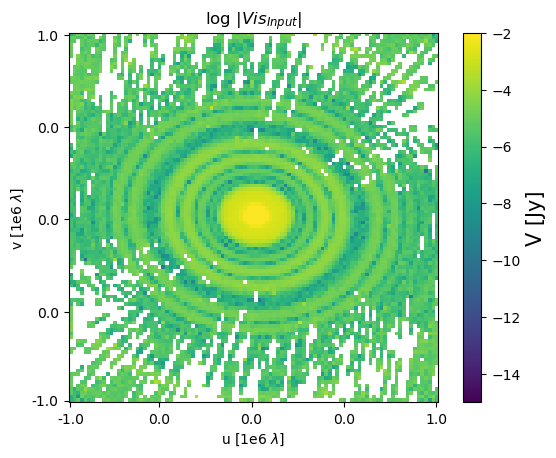

In [38]:
plt.imshow(np.log(np.abs(np.fft.fftshift(x_cpu.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

/tmp/ipykernel_1521242/3314022075.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(x_gpu.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)


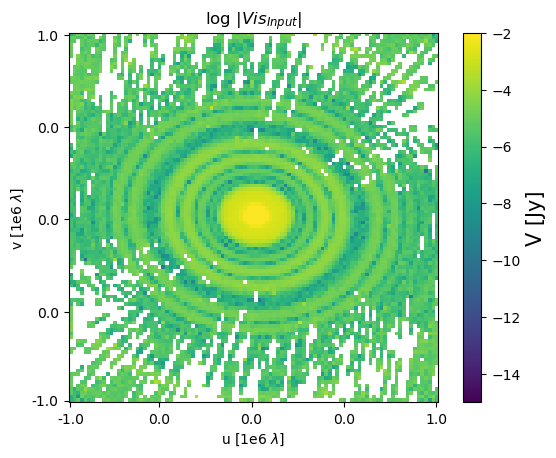

In [39]:
plt.imshow(np.log(np.abs(np.fft.fftshift(x_gpu.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

/tmp/ipykernel_1521242/1345077531.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift((x_cpu - x_gpu ).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)


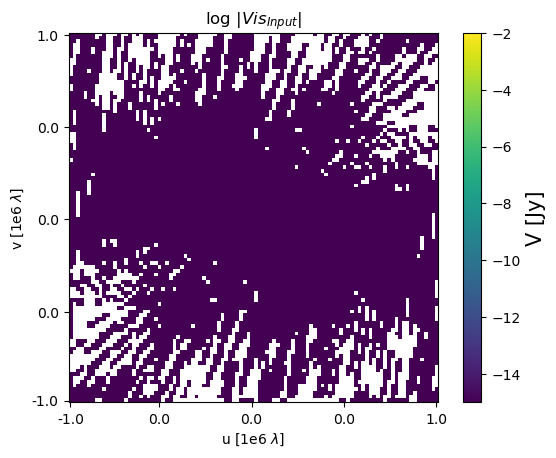

In [40]:
plt.imshow(np.log(np.abs(np.fft.fftshift((x_cpu - x_gpu ).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

**BUT THERE STILL SOME DIFFERENCES:the gridding in GPU is NOT totally fine.**

/tmp/ipykernel_1521242/773629069.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift((x_cpu - x_gpu ).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))))


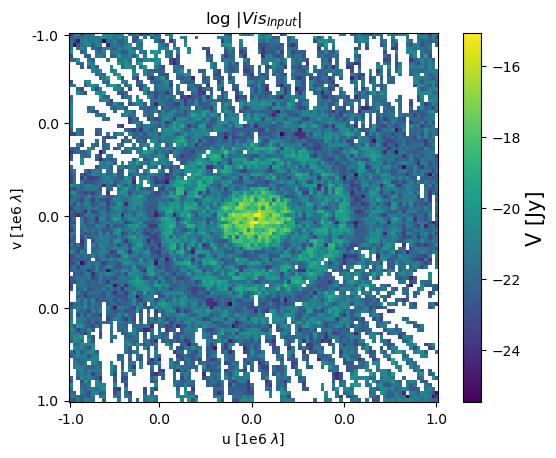

In [41]:
plt.imshow(np.log(np.abs(np.fft.fftshift((x_cpu - x_gpu ).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))))
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

##### What if we used the GPU values in the CPU algorithm?

In [42]:
from Frank2D_CPU import Frank2D_optimized

------> Creating linear operators
  --> time = 0.27  min |  16.39 seconds
---------------------------------
------> Creating sparse system
  --> time = 0.22  min |  13.49 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.24673735532842173
         * maxiter:  78570
.... iteration:  0
                        -> actual tol:  246737355.3284217 vs  0.24673735532842173
.... iteration:  1
                        -> actual tol:  52448835.855336726 vs  0.24673735532842173
.... iteration:  2
                        -> actual tol:  36140388.31369372 vs  0.24673735532842173
.... iteration:  3
                        -> actual tol:  26621086.519832376 vs  0.24673735532842173
.... iteration:  4
                        -> actual tol:  18676805.880853627 vs  0.24673735532842173
.... iteration:  5
                        -> actual tol:  12163026.01397634 vs  0.24673735532842173
.... iteration:  6
                        

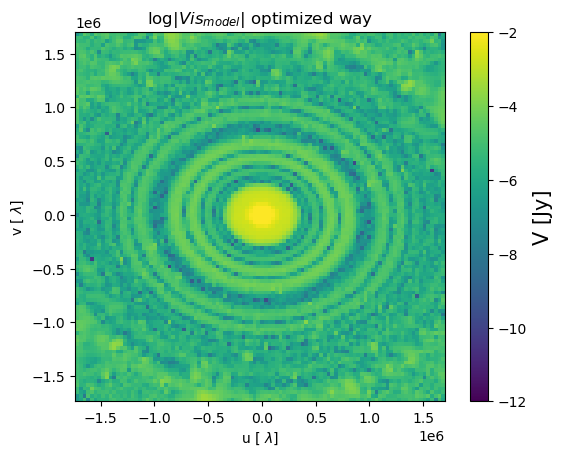

In [44]:
Frank2D_optimized(N, u_gridded_to_np, v_gridded_to_np, vis_gridded_to_np, weights_gridded_to_np)

#### Optimized algorithm

In [46]:
input = weights_gridded.reshape(N, N)

In [47]:
data_index = cp.argwhere(input.flatten() != 0)
no_data_index = cp.argwhere(input.flatten() == 0) 

In [48]:
# data
u_gridded_data = u_gridded[data_index].flatten()
v_gridded_data = v_gridded[data_index].flatten()
vis_gridded_data  = vis_gridded[data_index].flatten()
weights_gridded_data = weights_gridded[data_index].flatten()

In [49]:
u_gridded_no_data = u_gridded[no_data_index].flatten()
v_gridded_no_data = v_gridded[no_data_index].flatten()
vis_gridded_no_data  = vis_gridded[no_data_index].flatten()
weights_gridded_no_data = weights_gridded[no_data_index].flatten()

In [50]:
min_freq = cp.sort(cp.abs(cp.unique(v_gridded_data)))[1]

In [51]:
m , c,  l = -0.33, -0.1, 2e5

In [52]:
# Paper values for j = 4, k = 1
H_41 = 2*1.897367*l
C_41 = 7/cp.pi

In [53]:
info_mem()

Used memory: 55.57 MB
Free memory in pool: 64.72 MB


In [53]:
start_time = time.time()

print("------> Creating linear operators")
S11_linearOp = create_sparse_kernel(kernel_row, u_gridded_data, v_gridded_data)
S12_T_linearOp = create_sparse_kernel(kernel_row, u_gridded_data, v_gridded_data, u2 = u_gridded_no_data, v2 = v_gridded_no_data)

end_time = time.time()
execution_time = end_time - start_time
print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

------> Creating linear operators
  --> time = 3.33  min |  199.96 seconds


In [54]:
info_mem()

Used memory: 473.88 MB
Free memory in pool: 22024.29 MB


In [55]:
N_data = vis_gridded_data.shape[0]

import cupy as cp
from cupyx.scipy.sparse import csr_matrix

def create_sparse_system_data():
    # Initialize as CuPy arrays instead of Python lists
    data_A = cp.array([], dtype=cp.float32)
    indices_A = cp.array([], dtype=cp.int32)
    indptr_A = cp.zeros(N_data + 1, dtype=cp.int32)

    data_Aprecond = cp.array([], dtype=cp.float32)
    indices_Aprecond = cp.array([], dtype=cp.int32)
    indptr_Aprecond = cp.zeros(N_data + 1, dtype=cp.int32)

    weights = weights_gridded_data  # Assuming this is already a CuPy array

    for i in range(N_data):  
        row = kernel_row(u_gridded_data, v_gridded_data, i)
        non_zero_indices = cp.nonzero(row)[0]
        non_zero_values = row[non_zero_indices]

        Nm1_S_values = non_zero_values * weights[i]

        # A
        diagonal_pos = cp.where(non_zero_indices == i)[0][0]
        Nm1_S_values[diagonal_pos] += 1
        diag_value = Nm1_S_values[diagonal_pos]

        # Concatenate new values into CuPy arrays
        data_A = cp.concatenate((data_A, Nm1_S_values))
        indices_A = cp.concatenate((indices_A, non_zero_indices))
        indptr_A[i + 1] = data_A.size

        # Preconditioner of A
        data_Aprecond = cp.concatenate((data_Aprecond, cp.array([diag_value**(-1)])))
        indices_Aprecond = cp.concatenate((indices_Aprecond, cp.array([i])))
        indptr_Aprecond[i + 1] = data_Aprecond.size

    # Create sparse matrices in CuPy
    A_csr = csr_matrix((data_A, indices_A, indptr_A), shape=(N_data, N_data))
    A_precond_csr = csr_matrix((data_Aprecond, indices_Aprecond, indptr_Aprecond), shape=(N_data, N_data))

    # Convert to linear operators (assuming linear_operator is CuPy-compatible)
    A = linear_operator(A_csr, (N_data, N_data))
    A_precond = linear_operator(A_precond_csr, (N_data, N_data))

    # Compute b on the GPU
    b = weights * vis_gridded_data  # Ensure vis_gridded_data is also CuPy

    return A, A_precond, b

start_time = time.time()
print("------> Creating sparse system")

A_opt, A_precond_opt, b_opt = create_sparse_system_data()

end_time = time.time()
execution_time = end_time - start_time
print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

------> Creating sparse system
  --> time = 1.15  min |  69.24 seconds


In [ ]:
start_time = time.time()
print("------> Running CGM")

x_data, info = bicgstab_cupy(A_opt, b_opt, M = A_precond_opt, rtol = 1e-9)
C_ = x_data

# Report on the success of the fitting
print("  --> CGM converged?  ", info == 0)
fit_correctly = cp.allclose(A_opt.matvec(C_), b_opt)
print("  --> Fit correctly?  ", fit_correctly)
if fit_correctly:
    print("                                    !!!!!!!!!!!!!!!!!!!")

end_time = time.time()
execution_time = end_time - start_time
print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')


### Plots en CPU

In [ ]:
V_m = recovering_sol(C_)

In [ ]:
u_gridded_np = u_gridded.get()
v_gridded_np = v_gridded.get()
V_m_np = V_m.get()

In [ ]:
import numpy as np

In [ ]:
plt.pcolormesh(np.fft.fftshift(v_gridded_np.reshape(N, N)), np.fft.fftshift(u_gridded_np).reshape(N,N), np.log(np.abs(np.fft.fftshift(V_m_np))), cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)
plt.title(r'log|$Vis_{model}$| from matrix mult in GPU')
plt.show()

In [ ]:
x_ = frank2d._FT._Xn * rad_to_arcsec
y_ = frank2d._FT._Yn * rad_to_arcsec

In [ ]:
plt.pcolormesh(x_.reshape(N, N), y_.reshape(N, N), cp.fft.fftshift(cp.fft.ifft2(V_m).real).get()/(frank2d._FT._dx * frank2d._FT._dy), cmap = 'magma')
plt.gca().invert_xaxis()
plt.colorbar()
plt.show()